### Setup dell'ambiente

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Installazione pacchetti (locale)
# (in Colab sarà uguale, basta togliere "opencv-python" e usare "opencv-python-headless")
!pip install ultralytics opencv-python-headless scipy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.3 MB/s eta 0:00:00


In [ ]:
import os, cv2, glob
from ultralytics import YOLO

# Cartelle locali (modifica se serve)
HOME_DIR = "/content/drive/MyDrive/deep-learning-project/"
DATA_DIR = f"{HOME_DIR}data"        # dataset scaricato a mano o da Kaggle
OUT_DIR = f"{HOME_DIR}dataset"      # dataset convertito per YOLO

### Finetuning YOLO

In [ ]:
# Inizializza modello (nano per velocità)
model = YOLO(f"{HOME_DIR}yolov8n.pt")

# Addestramento
model.train(
    data=f"{OUT_DIR}/football.yaml",
    epochs=20, imgsz=640, batch=16,
    augment=True,
    project = HOME_DIR,
    name = "yolov8n-aug-bs16"
    )

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/deep-learning-project/dataset/football.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/deep-learning-project/yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n-aug-bs16, nbs=64, nms=False, opset=None, optimiz

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79077ad82270>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

### Prova di inferenza con algoritmo di tracking (con salvataggio video)

In [ ]:
# Carica modello addestrato
model = YOLO(f"{HOME_DIR}yolov8n/weights/best.pt")

# Tracking con algoritmo ByteTrack integrato
results = model.track(
    source=f"{HOME_DIR}/input_videos/video.mp4",
    tracker="bytetrack.yaml",
    conf=0.60,
    save=True,
    project=f"{HOME_DIR}track",
    name="yolov8n"
)


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/4949) /content/drive/MyDrive/deep-learning-project/video.mp4: 384x640 (no detections), 14.2ms
video 1/1 (frame 2/4949) /content/drive/MyDrive/deep-learning-project/video.mp4: 384x640 (no detections), 7.0ms
video 1/1 (frame 3/4949) /content/drive/MyDrive/deep-learning-project/video.mp4: 384x640 (no detections), 6.4ms
video 1/1 (frame 4/4949) /content/drive/MyDrive/deep-learning-project/video.mp4: 384x640 (no detections), 7.0ms
video 1



---


### **PIPELINE COMPLETA** (con modello YOLO già finetunato)

### Inizializzazione e setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Installazione pacchetti (locale)
!pip install ultralytics opencv-python-headless scipy tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install ultralytics scipy tqdm opencv-python-headless torch Pillow
!pip install git+https://github.com/facebookresearch/segment-anything-2.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-48m4dyyq
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-48m4dyyq
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=648b00825a83be71e9275e6fb19099deda92a5501b189009c14f93a68193d80b
  Stored in directory: /tmp/pip-ephem-wheel-cache-ygr3fgtq/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
  Cloning https://github.com/facebookresearch/segment-anything-2.git to /tmp/pip-req-build-d9trxxik
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything-2.git /tmp/pip-req-build-d9trxxik
  Resolved https://github.com/facebookresearch/segme

In [ ]:
import cv2
import numpy as np
import torch
from ultralytics import YOLO
import clip
from PIL import Image
import torch.nn.functional as F
import random
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- CONFIGURAZIONE ---
HOME_DIR = "/content/drive/MyDrive/deep-learning-project/"
video_path = f"{HOME_DIR}/input_videos/video1.mp4"           # video di input
output_path = f"{HOME_DIR}video_annotated.mp4"  # video di output
yolo_model_path = f"{HOME_DIR}yolov8n-aug-bs16/weights/best.pt"       # modello YOLO addestrato
tracker_yaml = "bytetrack.yaml"      # tracker
conf_threshold = 0.6                 # soglia YOLO
clip_threshold = 0.8                 # soglia cosine similarity per contenuto

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# --- CARICA SAM2 ---
from sam2.sam2_image_predictor import SAM2ImagePredictor

predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2.1-hiera-tiny")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


sam2.1_hiera_tiny.pt:   0%|          | 0.00/156M [00:00<?, ?B/s]

In [ ]:
# --- CARICA MODELLI YOLO+CLIP ---
model = YOLO(yolo_model_path)
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# --- Dizionario globale embeddings ---
embeddings = {}

100%|███████████████████████████████████████| 338M/338M [00:15<00:00, 23.2MiB/s]


In [ ]:
# --- Funzioni helper ---
def assign_content_ids(segmented, clip_model, clip_preprocess, prev_embeddings=None, threshold=0.25, device="cuda"):
    """
    Assegna content-ID ai banner segmentati usando CLIP.
    """
    if prev_embeddings is None:
        prev_embeddings = {}

    assigned = []
    next_content_id = max(prev_embeddings.keys(), default=0) + 1

    with torch.no_grad():
        for detection in segmented:
            crop = detection["crop"]

            # Converti crop in formato PIL per CLIP
            if crop is None or crop.size == 0:
                assigned.append({**detection, "content_id": -1})
                continue

            try:
                # CORREZIONE: Rimuovi i pixel neri prima di processare con CLIP
                crop_cleaned = remove_black_background(crop)

                if crop_cleaned is None:
                    assigned.append({**detection, "content_id": -1})
                    continue

                # Converti BGR->RGB
                if len(crop_cleaned.shape) == 3 and crop_cleaned.shape[2] == 3:
                    crop_rgb = cv2.cvtColor(crop_cleaned, cv2.COLOR_BGR2RGB)
                else:
                    crop_rgb = crop_cleaned

                # Converti in PIL Image
                pil_image = Image.fromarray(crop_rgb)

                # Preprocessing per CLIP
                image_input = clip_preprocess(pil_image).unsqueeze(0).to(device)

                # Calcola embedding
                current_embedding = clip_model.encode_image(image_input)
                current_embedding = current_embedding / current_embedding.norm(dim=-1, keepdim=True)

                # Trova il content_id più simile
                best_similarity = -1
                best_content_id = None

                for content_id, stored_embedding in prev_embeddings.items():
                    stored_embedding = stored_embedding.to(device)

                    similarity = F.cosine_similarity(
                        current_embedding,
                        stored_embedding,
                        dim=-1
                    ).item()

                    if similarity > best_similarity:
                        best_similarity = similarity
                        best_content_id = content_id

                # Assegna ID basato sulla similarità
                if best_similarity > threshold:
                    assigned_id = best_content_id
                    # Aggiorna embedding con media mobile
                    alpha = 0.7
                    prev_embeddings[assigned_id] = (
                        alpha * prev_embeddings[assigned_id].to(device) +
                        (1 - alpha) * current_embedding
                    ).cpu()
                else:
                    # Nuovo contenuto
                    assigned_id = next_content_id
                    prev_embeddings[assigned_id] = current_embedding.cpu()
                    next_content_id += 1

                assigned.append({
                    **detection,
                    "content_id": assigned_id,
                    "similarity": best_similarity
                })

            except Exception as e:
                print(f"Errore CLIP processing per detection: {e}")
                assigned.append({**detection, "content_id": -1})

    return assigned, prev_embeddings

def prepare_clip_crops(results):
    frames = []
    boxes_lists = []

    for result in results:
        # Estrai frame - usa direttamente result.orig_img
        frame = result.orig_img.copy()
        frames.append(frame)

        # Estrai boxes
        frame_boxes = []
        if result.boxes is not None and len(result.boxes.xyxy) > 0:
            for i in range(len(result.boxes.xyxy)):
                bbox_dict = {
                    "xyxy": result.boxes.xyxy[i],
                    "conf": result.boxes.conf[i] if result.boxes.conf is not None else 1.0,
                    "cls": result.boxes.cls[i] if result.boxes.cls is not None else 0,
                    "id": result.boxes.id[i] if result.boxes.id is not None else i
                }
                frame_boxes.append(bbox_dict)

        boxes_lists.append(frame_boxes)

    return frames, boxes_lists

def run_sam_on_detections(frames, detections, sam_predictor):
    """
    Applica SAM2 alle bounding box fornite da YOLO+Tracker e restituisce i crop segmentati.
    """
    import numpy as np
    segmented = []

    for frame_idx, (frame, frame_detections) in enumerate(zip(frames, detections)):
        frame_segmented = []

        if len(frame_detections) == 0:
            segmented.append(frame_segmented)
            continue

        # Imposta l'immagine per SAM2
        sam_predictor.set_image(frame)

        for detection in frame_detections:
            try:
                # Estrai bbox
                xyxy = detection["xyxy"]
                if hasattr(xyxy, "cpu"):
                    xyxy = xyxy.cpu().numpy()
                xyxy = xyxy.flatten()
                x1, y1, x2, y2 = map(int, xyxy)

                # Verifica che la bbox sia valida
                if x2 <= x1 or y2 <= y1:
                    print(f"Bbox non valida frame {frame_idx}: {x1},{y1},{x2},{y2}")
                    continue

                # Usa la bbox come prompt per SAM2
                input_box = np.array([x1, y1, x2, y2])

                # Genera maschera con SAM2
                masks, scores, logits = sam_predictor.predict(
                    point_coords=None,
                    point_labels=None,
                    box=input_box[None, :],
                    multimask_output=False,
                )

                # Prendi la migliore maschera e assicurati sia booleana
                mask = masks[0]  # shape: (H, W)
                if mask.dtype != bool:
                    mask = mask.astype(bool)

                # Crea crop segmentato
                segmented_crop = apply_mask_to_crop(frame, mask, x1, y1, x2, y2)

                # Aggiungi ai risultati
                frame_segmented.append({
                    "xyxy": xyxy,
                    "mask": mask,
                    "crop": segmented_crop,
                    "track_id": detection.get("id", -1),  # Cambiato da track_id a id
                    "conf": detection.get("conf", 0.0)
                })

            except Exception as e:
                print(f"Errore SAM2 frame {frame_idx}: {e}")
                # Fallback: crop rettangolare normale
                try:
                    normal_crop = frame[y1:y2, x1:x2]
                    frame_segmented.append({
                        "xyxy": xyxy,
                        "mask": None,
                        "crop": normal_crop,
                        "track_id": detection.get("id", -1),
                        "conf": detection.get("conf", 0.0)
                    })
                except:
                    # Skip questa detection se anche il fallback fallisce
                    continue

        segmented.append(frame_segmented)

    return segmented

def apply_mask_to_crop(frame, mask, x1, y1, x2, y2):
    """
    Applica la maschera al crop e restituisce l'immagine segmentata con sfondo trasparente.
    """
    # Crop della regione
    crop = frame[y1:y2, x1:x2].copy()
    crop_mask = mask[y1:y2, x1:x2]

    # Assicurati che la maschera sia booleana
    if crop_mask.dtype != bool:
        crop_mask = crop_mask.astype(bool)

    # Applica maschera (pixel non-mask diventano neri)
    crop[~crop_mask] = [0, 0, 0]  # sfondo nero

    return crop

def extract_crop_from_mask(image, mask, bbox):
    """
    Estrae il crop dall'immagine usando la maschera SAM2
    """
    x1, y1, x2, y2 = map(int, bbox)

    # Estrai la regione di interesse
    roi = image[y1:y2, x1:x2].copy()
    mask_roi = mask[y1:y2, x1:x2]

    # CORREZIONE: Assicurati che mask_roi sia booleano
    if mask_roi.dtype != bool:
        mask_roi = mask_roi.astype(bool)

    # Applica la maschera: sfondo nero dove mask=False
    roi[~mask_roi] = 0

    return roi


def remove_black_background(crop, black_threshold=10):
    """
    Rimuove lo sfondo nero dal crop, mantenendo solo i pixel colorati.

    Args:
        crop: immagine crop con sfondo nero
        black_threshold: soglia per considerare un pixel "nero"

    Returns:
        crop pulito senza sfondo nero, o None se troppo piccolo
    """
    # Trova pixel non neri
    if len(crop.shape) == 3:
        # Calcola la somma dei canali per identificare pixel non neri
        pixel_sum = np.sum(crop, axis=2)
        non_black_mask = pixel_sum > black_threshold
    else:
        non_black_mask = crop > black_threshold

    # Se ci sono troppo pochi pixel non neri, skippa
    non_black_pixels = np.sum(non_black_mask)
    total_pixels = crop.shape[0] * crop.shape[1]

    # Trova bounding box dei pixel non neri
    rows = np.any(non_black_mask, axis=1)
    cols = np.any(non_black_mask, axis=0)

    if not np.any(rows) or not np.any(cols):
        return None

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Estrai solo la regione con contenuto
    if len(crop.shape) == 3:
        cropped_content = crop[rmin:rmax+1, cmin:cmax+1, :]
    else:
        cropped_content = crop[rmin:rmax+1, cmin:cmax+1]

    # Ridimensiona se troppo piccolo
    min_size = 32
    if cropped_content.shape[0] < min_size or cropped_content.shape[1] < min_size:
        if len(cropped_content.shape) == 3:
            cropped_content = cv2.resize(cropped_content, (min_size, min_size))
        else:
            cropped_content = cv2.resize(cropped_content, (min_size, min_size))

    return cropped_content



### Tracking con YOLO+ByteTrack

In [ ]:
# --- TRACKING ---

results = model.track(
      source=video_path,
      tracker=tracker_yaml,
      conf=conf_threshold,
      save=False
  )


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/3591) /content/drive/MyDrive/deep-learning-project/input_videos/video1.mp4: 384x640 1 adboard, 10.3ms
video 1/1 (frame 2/3591) /content/drive/MyDrive/deep-learning-project/input_videos/video1.mp4: 384x640 1 adboard, 10.8ms
video 1/1 (frame 3/3591) /content/drive/MyDrive/deep-learning-project/input_videos/video1.mp4: 384x640 1 adboard, 10.5ms
video 1/1 (frame 4/3591) /content/drive/MyDrive/deep-learning-project/input_videos/video1.mp4

In [ ]:
frames, boxes_lists = prepare_clip_crops(results)

### Prova di segmentazione

🎲 Test SAM2 su frame RANDOM 1989 (su 4949 totali)
   Frame con detection disponibili: 1771
   Detection in questo frame: 1
✅ Test completato - 1 detection processate

🎯 Visualizzando detection random #0:
   - Bbox: (0,57) -> (640,183)
   - Dimensioni: 640x126
   - Track ID: 24.0
   - Mask presente: True

📊 Statistiche dettagliate:
   Frame size: 640x360 = 230,400 pixel
   Bbox size: 640x126 = 80,640 pixel
   Pixel maschera totali: 14,090 (6.12% del frame)
   Pixel maschera nella bbox: 14,090 (17.5% della bbox)
   Precisione SAM2: 100.0% della maschera è nella bbox


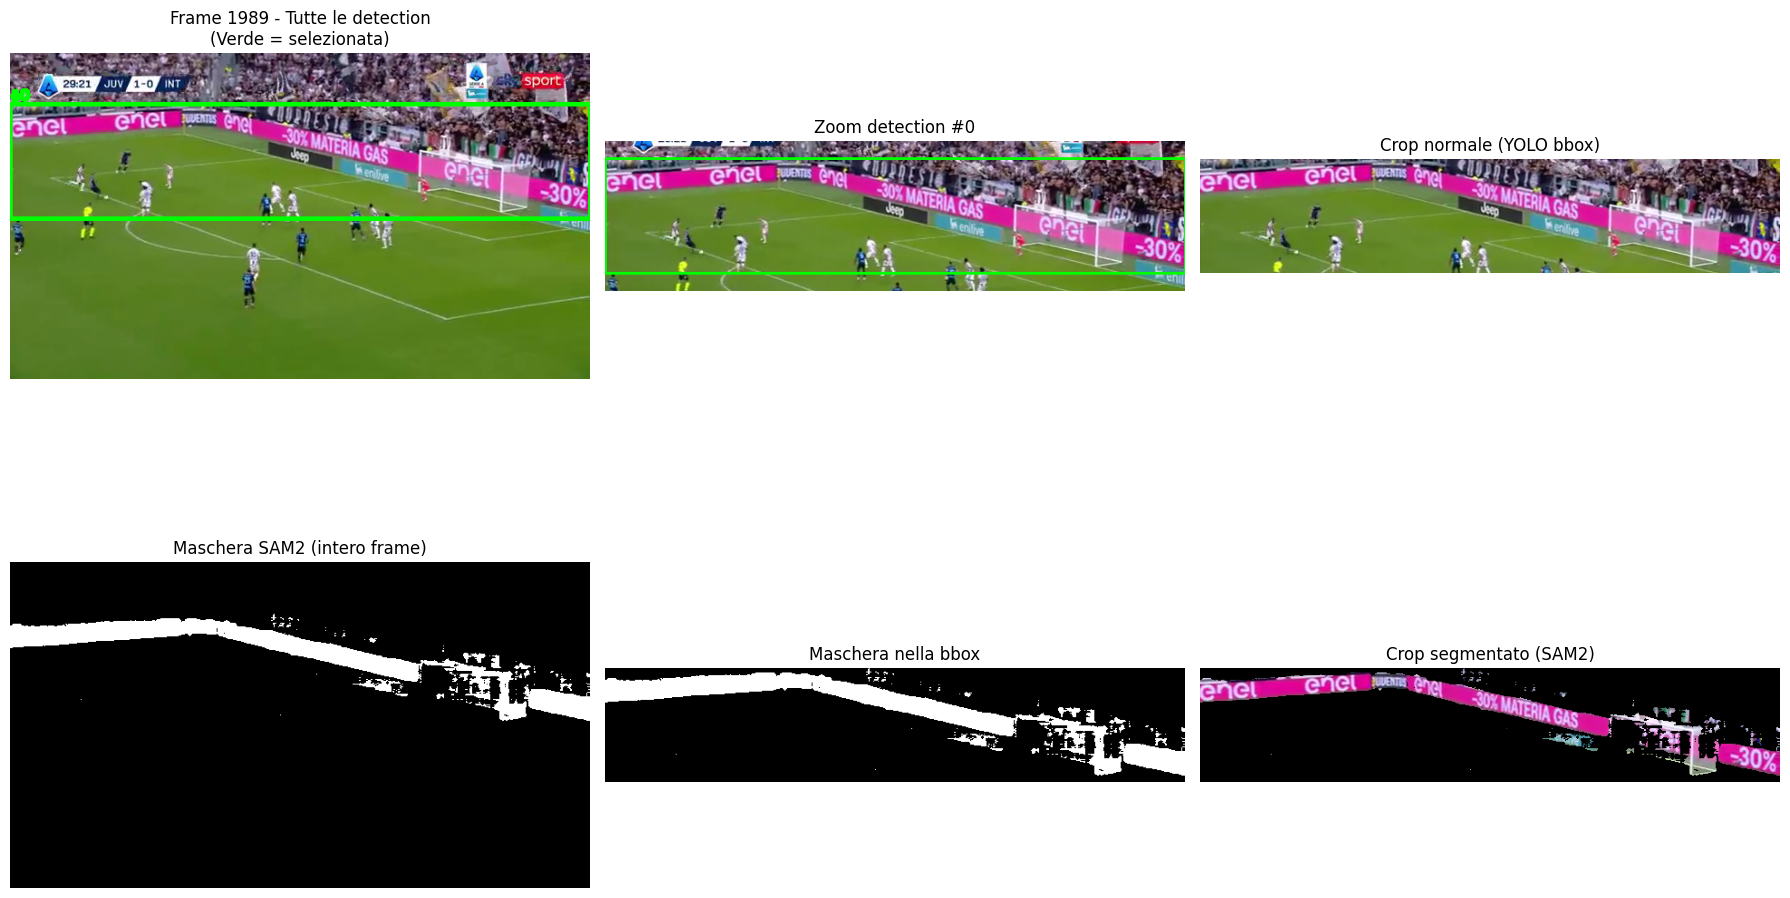


📋 Altre detection in questo frame:


In [ ]:
### Test SAM2 su frame random con visualizzazione

import matplotlib.pyplot as plt
import numpy as np
import random

# Trova tutti i frame con detection
frames_with_detections = []
for i, boxes in enumerate(boxes_lists):
    if len(boxes) > 0:
        frames_with_detections.append(i)

if len(frames_with_detections) > 0:
    # Scegli frame random tra quelli con detection
    random_frame_idx = random.choice(frames_with_detections)
    print(f"🎲 Test SAM2 su frame RANDOM {random_frame_idx} (su {len(frames)} totali)")
    print(f"   Frame con detection disponibili: {len(frames_with_detections)}")
    print(f"   Detection in questo frame: {len(boxes_lists[random_frame_idx])}")

    # Test su frame random
    test_frames = [frames[random_frame_idx]]
    test_boxes = [boxes_lists[random_frame_idx]]

    segmented_test = run_sam_on_detections(test_frames, test_boxes, predictor)

    if len(segmented_test) > 0 and len(segmented_test[0]) > 0:
        frame = frames[random_frame_idx]
        detections = segmented_test[0]

        print(f"✅ Test completato - {len(detections)} detection processate")

        # Scegli detection random da visualizzare
        random_det_idx = random.randint(0, len(detections) - 1)
        det = detections[random_det_idx]

        # Estrai dati
        xyxy = det['xyxy']
        x1, y1, x2, y2 = map(int, xyxy)
        mask = det['mask']
        crop = det['crop']
        track_id = det['track_id']

        print(f"\n🎯 Visualizzando detection random #{random_det_idx}:")
        print(f"   - Bbox: ({x1},{y1}) -> ({x2},{y2})")
        print(f"   - Dimensioni: {x2-x1}x{y2-y1}")
        print(f"   - Track ID: {track_id}")
        print(f"   - Mask presente: {mask is not None}")

        # Visualizzazione completa
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # 1. Frame originale con tutte le bbox
        frame_with_all_boxes = frame.copy()
        for i, d in enumerate(detections):
            xyxy_d = d['xyxy']
            x1_d, y1_d, x2_d, y2_d = map(int, xyxy_d)
            color = (0, 255, 0) if i == random_det_idx else (255, 0, 0)
            thickness = 3 if i == random_det_idx else 1
            cv2.rectangle(frame_with_all_boxes, (x1_d, y1_d), (x2_d, y2_d), color, thickness)
            cv2.putText(frame_with_all_boxes, f"#{i}", (x1_d, y1_d-5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, thickness)

        axes[0,0].imshow(cv2.cvtColor(frame_with_all_boxes, cv2.COLOR_BGR2RGB))
        axes[0,0].set_title(f"Frame {random_frame_idx} - Tutte le detection\n(Verde = selezionata)")
        axes[0,0].axis('off')

        # 2. Zoom sulla detection selezionata
        padding = 20
        x1_zoom = max(0, x1 - padding)
        y1_zoom = max(0, y1 - padding)
        x2_zoom = min(frame.shape[1], x2 + padding)
        y2_zoom = min(frame.shape[0], y2 + padding)

        zoomed_frame = frame[y1_zoom:y2_zoom, x1_zoom:x2_zoom].copy()
        # Disegna bbox relativa al crop
        rel_x1, rel_y1 = x1 - x1_zoom, y1 - y1_zoom
        rel_x2, rel_y2 = x2 - x1_zoom, y2 - y1_zoom
        cv2.rectangle(zoomed_frame, (rel_x1, rel_y1), (rel_x2, rel_y2), (0, 255, 0), 2)

        axes[0,1].imshow(cv2.cvtColor(zoomed_frame, cv2.COLOR_BGR2RGB))
        axes[0,1].set_title(f"Zoom detection #{random_det_idx}")
        axes[0,1].axis('off')

        # 3. Crop normale (bbox)
        normal_crop = frame[y1:y2, x1:x2]
        axes[0,2].imshow(cv2.cvtColor(normal_crop, cv2.COLOR_BGR2RGB))
        axes[0,2].set_title("Crop normale (YOLO bbox)")
        axes[0,2].axis('off')

        if mask is not None:
            # 4. Maschera SAM2 completa
            axes[1,0].imshow(mask, cmap='gray')
            axes[1,0].set_title("Maschera SAM2 (intero frame)")
            axes[1,0].axis('off')

            # 5. Maschera nella bbox
            mask_crop = mask[y1:y2, x1:x2]
            axes[1,1].imshow(mask_crop, cmap='gray')
            axes[1,1].set_title("Maschera nella bbox")
            axes[1,1].axis('off')

            # 6. Crop segmentato finale
            axes[1,2].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            axes[1,2].set_title("Crop segmentato (SAM2)")
            axes[1,2].axis('off')

            # Statistiche dettagliate
            total_pixels = mask.shape[0] * mask.shape[1]
            mask_pixels = np.sum(mask)
            bbox_area = (x2 - x1) * (y2 - y1)
            mask_in_bbox = np.sum(mask_crop)

            print(f"\n📊 Statistiche dettagliate:")
            print(f"   Frame size: {frame.shape[1]}x{frame.shape[0]} = {total_pixels:,} pixel")
            print(f"   Bbox size: {x2-x1}x{y2-y1} = {bbox_area:,} pixel")
            print(f"   Pixel maschera totali: {mask_pixels:,} ({mask_pixels/total_pixels*100:.2f}% del frame)")
            print(f"   Pixel maschera nella bbox: {mask_in_bbox:,} ({mask_in_bbox/bbox_area*100:.1f}% della bbox)")
            print(f"   Precisione SAM2: {mask_in_bbox/mask_pixels*100:.1f}% della maschera è nella bbox")

        else:
            # Nessuna maschera - mostra messaggio
            for ax in [axes[1,0], axes[1,1], axes[1,2]]:
                ax.text(0.5, 0.5, "❌ SAM2 fallito\nUsando crop normale",
                       ha='center', va='center', fontsize=12,
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
                ax.axis('off')

        plt.tight_layout()
        plt.show()

        # Info aggiuntive sulle altre detection nello stesso frame
        print(f"\n📋 Altre detection in questo frame:")
        for i, d in enumerate(detections):
            if i != random_det_idx:
                xyxy_d = d['xyxy']
                x1_d, y1_d, x2_d, y2_d = map(int, xyxy_d)
                has_mask = d['mask'] is not None
                print(f"   Detection #{i}: ({x1_d},{y1_d})->({x2_d},{y2_d}), "
                      f"size={x2_d-x1_d}x{y2_d-y1_d}, "
                      f"SAM2={'✅' if has_mask else '❌'}")

    else:
        print("❌ Errore nel test SAM2 su frame random")

else:
    print("❌ Nessun frame con detection trovato!")

### Esecuzione SAM2 + CLIP (frame-by-frame)

In [ ]:
# Invece di processare tutto in una volta, processa frame per frame
import torch, clip, cv2, random
import importlib

# Carica modello CLIP
device = "cuda" if torch.cuda.is_available() else "cpu"
clipmodel, preprocess = clip.load("ViT-B/32", device=device)

# Prepara video output
height, width = frames[0].shape[:2]
out = cv2.VideoWriter(f"{HOME_DIR}output_sam2.mp4", cv2.VideoWriter_fourcc(*'mp4v'), 30, (width, height))

embeddings = {}
colors = {}

# PROCESSAMENTO FRAME BY FRAME (MEMORY EFFICIENT)
for frame_idx, (frame, boxes) in enumerate(zip(frames, boxes_lists)):

    # Segmenta solo il frame corrente
    frame_detections = []

    if len(boxes) > 0:
        predictor.set_image(frame)

        for box in boxes:
            try:
                # Estrai xyxy dal dizionario e converti da tensor a numpy
                xyxy_tensor = box['xyxy']

                # Converti tensor a numpy e poi a lista
                if hasattr(xyxy_tensor, 'cpu'):  # Se è su GPU
                    xyxy_np = xyxy_tensor.cpu().numpy()
                else:  # Se è già su CPU
                    xyxy_np = xyxy_tensor.numpy()

                input_box = np.array([xyxy_np[0], xyxy_np[1], xyxy_np[2], xyxy_np[3]])

            except Exception as e:
                print(f"Errore processing box {box}: {e}")
                continue

            masks, scores, _ = predictor.predict(
                point_coords=None,
                point_labels=None,
                box=input_box[None, :],
                multimask_output=False,
            )

            mask = masks[0]
            crop = extract_crop_from_mask(frame, mask, input_box)

            frame_detections.append({
                'xyxy': input_box,
                'crop': crop,
                'mask': mask
            })

    # Assegna content ID immediatamente
    try:
        assigned, embeddings = assign_content_ids(
            frame_detections,
            clipmodel,
            preprocess,
            prev_embeddings=embeddings,
            threshold=0.75,
            device=device
        )
    except Exception as e:
        print(f"Errore CLIP processing: {e}")
        # Se CLIP fallisce, mantieni le detection senza content ID
        assigned = []
        for detection in frame_detections:
            detection['content_id'] = -1
            assigned.append(detection)

    # Disegna e salva frame
    for detection in assigned:
        xyxy = detection["xyxy"]
        x1, y1, x2, y2 = map(int, xyxy)
        content_id = detection["content_id"]
        mask = detection.get("mask")

        if content_id == -1:
            continue

        if content_id not in colors:
            colors[content_id] = [random.randint(0,255) for _ in range(3)]

        color = colors[content_id]

        cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
        cv2.putText(frame, f"Content:{content_id}", (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        if mask is not None:
            # Converti maschera SAM2 in booleano
            if mask.dtype == np.uint8:
                mask_bool = mask > 0  # SAM2 usa 0/255, converti in True/False
            elif mask.dtype == bool:
                mask_bool = mask
            else:
                mask_bool = mask.astype(bool)

            colored_mask = np.zeros_like(frame)
            colored_mask[mask_bool] = color
            frame = cv2.addWeighted(frame, 0.8, colored_mask, 0.2, 0)  # Alpha più visibile

    out.write(frame)

    # Pulizia memoria ogni 10 frame
    if frame_idx % 10 == 0:
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print(f"Processato frame {frame_idx}/{len(frames)}")

out.release()
print(f"Video salvato in output_sam2_framebased.mp4")
print(f"Content ID trovati: {sorted(colors.keys())}")

Processato frame 0/3591
Processato frame 10/3591
Processato frame 20/3591
Processato frame 30/3591
Processato frame 40/3591
Processato frame 50/3591
Processato frame 60/3591
Processato frame 70/3591
Processato frame 80/3591
Processato frame 90/3591
Processato frame 100/3591
Processato frame 110/3591
Processato frame 120/3591
Processato frame 130/3591
Processato frame 140/3591
Processato frame 150/3591
Processato frame 160/3591
Processato frame 170/3591
Processato frame 180/3591
Processato frame 190/3591
Processato frame 200/3591
Processato frame 210/3591
Processato frame 220/3591
Processato frame 230/3591
Processato frame 240/3591
Processato frame 250/3591
Processato frame 260/3591
Processato frame 270/3591
Processato frame 280/3591
Processato frame 290/3591
Processato frame 300/3591
Processato frame 310/3591
Processato frame 320/3591
Processato frame 330/3591
Processato frame 340/3591
Processato frame 350/3591
Processato frame 360/3591
Processato frame 370/3591
Processato frame 380/35